# How to Generate Synthetic Data When Your Data Has Null Values

When you pass data with missing values to SDV, nulls are handled automatically. You don't need to clean or impute them yourself — SDV's preprocessing layer takes care of filling in nulls before the synthesizer trains, and then reintroduces them into the synthetic output.

This cookbook walks you through the default behavior, shows you how to customize it when the defaults aren't enough, and highlights common pitfalls to avoid along the way.

**When to use this cookbook:** You have a dataset with missing values and want to generate synthetic data that preserves the null patterns from your real data.

## 1. Loading and exploring the dataset

We'll work with the `null_values_demo_dataset`, a single-table dataset designed for this cookbook. It contains columns with varying amounts of missing values — from 0% to 100% — making it a good stress test for null handling.

In [1]:
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')

from sdv.datasets.demo import download_demo

data, metadata = download_demo(
    modality='single_table',
    dataset_name='null_values_demo_dataset'
)

data.head()

,ticket_id,created_at,customer_email,priority,category,is_escalated,response_time_hours,resolution_time_hours,satisfaction_score,internal_notes_count,resolved_at,resolution_status,agent_name,response_time_legacy,customer_phone,num_reassignments,customer_notes
0,TKT-00000,2025-09-26 12:36:44,james.davis@gmail.com,Medium,Technical,False,1.61,NaN,NaN,NaN,NaN,NaN,NaN,1.61,(713) 584-8784,1.0,NaN
1,TKT-00001,2025-07-06 06:41:18,linda.jones_760@gmail.com,Critical,Billing,False,0.95,3.05,NaN,NaN,2025-07-06 09:44:18,Resolved,Derek Patel,0.95,(206) 459-3081,3.0,NaN
2,TKT-00002,2025-09-27 23:57:30,NaN,Critical,Technical,False,4.50,14.60,NaN,NaN,2025-09-28 14:33:30,Workaround,Raymond Reddington,4.50,(415) 598-6575,0.0,NaN
3,TKT-00003,2025-11-07 20:42:47,patricia.miller@outlook.com,Medium,Feature Request,False,NaN,17.29,3.0,NaN,2025-11-08 14:00:11,Resolved,Marko Zakic,-1.00,NaN,2.0,NaN
4,TKT-00004,2025-09-02 00:03:08,michael.wilson@gmail.com,Medium,Bug Report,NaN,1.61,34.52,NaN,NaN,2025-09-03 10:34:20,Workaround,Raymond Reddington,1.61,(310) 613-5736,1.0,NaN


**What are the null rates across columns?**

In [2]:
data.isnull().mean().round(3)

ticket_id                0.000
created_at               0.000
customer_email           0.101
priority                 0.000
category                 0.146
is_escalated             0.200
response_time_hours      0.049
resolution_time_hours    0.305
satisfaction_score       0.684
internal_notes_count     0.928
resolved_at              0.305
resolution_status        0.305
agent_name               0.078
response_time_legacy     0.000
customer_phone           0.252
num_reassignments        0.195
customer_notes           1.000
dtype: float64

The null rates range from 0% (columns like `ticket_id` and `priority`) all the way to 100% (`customer_notes`, which is entirely null). Some columns share a similar null rate — for example, `resolution_time_hours`, `resolved_at`, and `resolution_status` are all around 30%, hinting that they might be null together. We'll investigate this pattern later in Section 7.

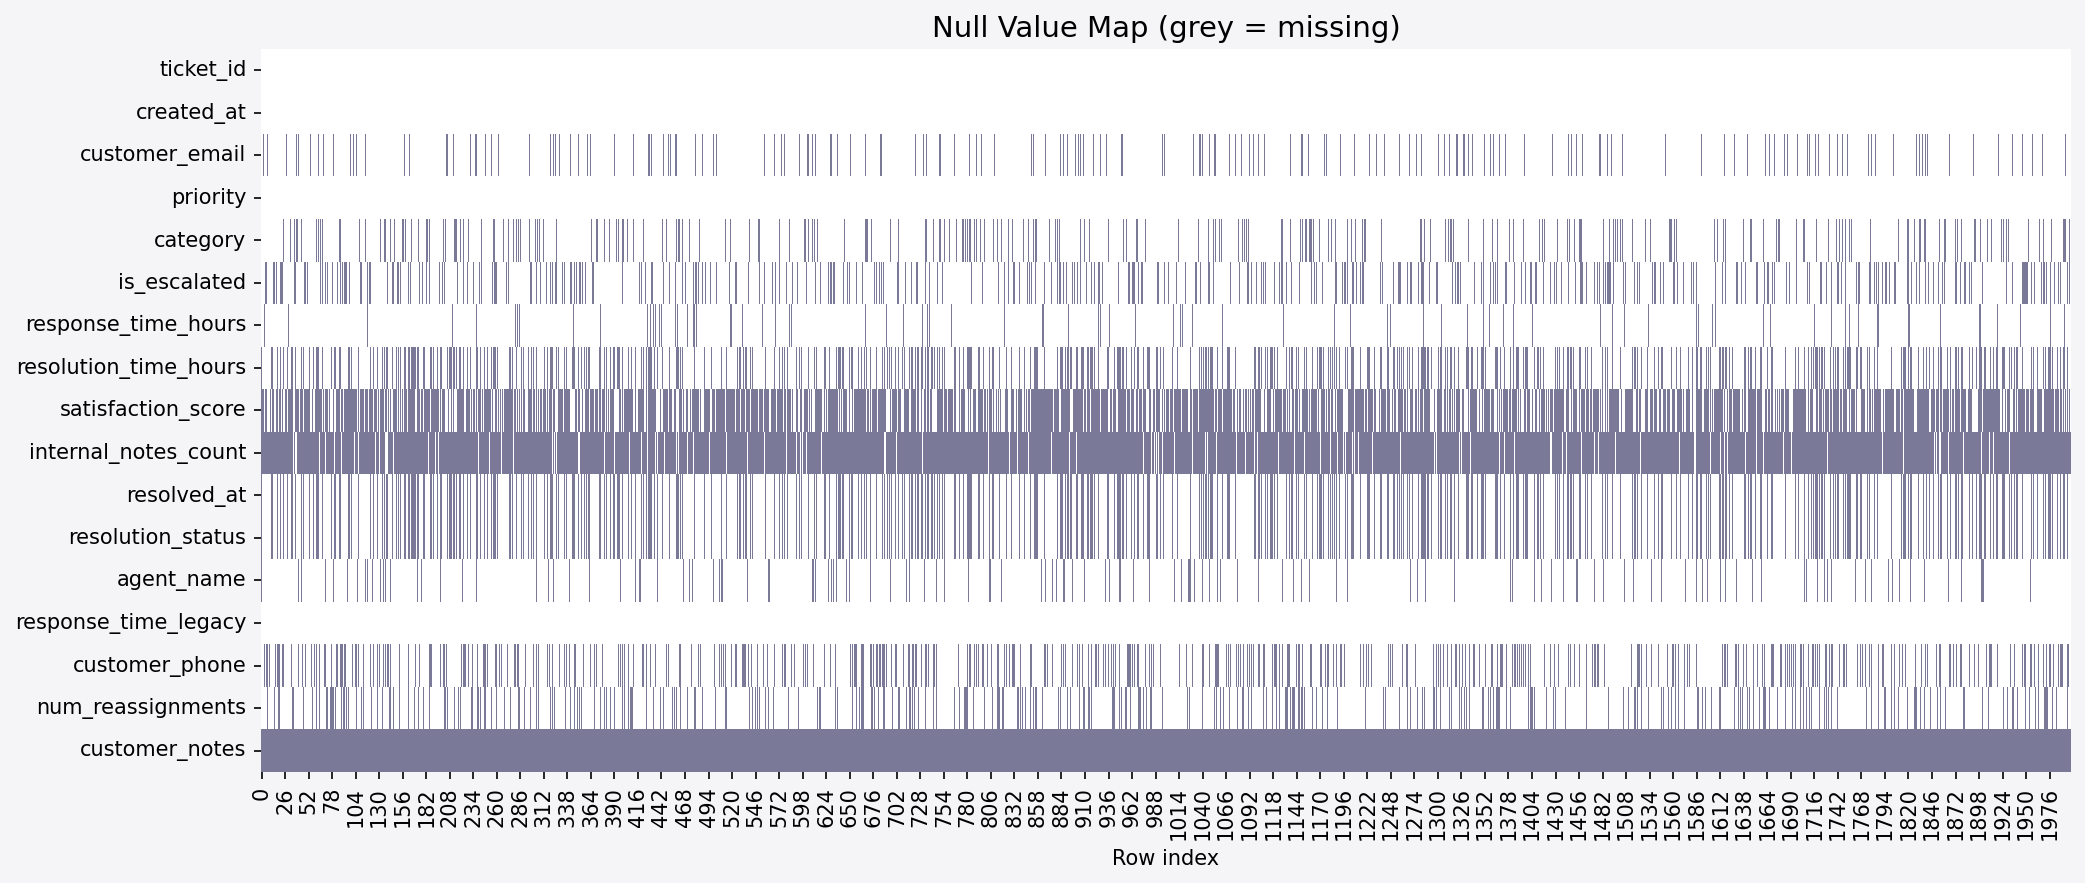

## 2. Understanding the metadata

The metadata describes the structure of our dataset — the type of each column (its `sdtype`), which drives how SDV handles missing values during preprocessing. Let's look at the metadata that came with the dataset:

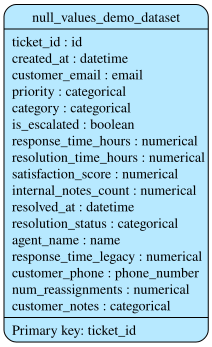

In [3]:
metadata.visualize()

Each column has an `sdtype` — numerical, categorical, datetime, email, phone, or id. The sdtype determines how nulls are handled: numerical columns get their missing values filled with the column mean before training, categorical columns treat null as just another category, and PII columns like email and phone regenerate values using Faker while reintroducing nulls at the original rate.

## 3. Generating synthetic data with default settings

Generating synthetic data from a dataset with nulls requires no special configuration. Just create a synthesizer, fit it to the data, and sample. The `GaussianCopulaSynthesizer` is a good starting point — it uses classic statistical methods, produces high-quality results, and supports extensive customization.

We use `AnonymizedFaker` for the phone column to generate plausible phone numbers that aren't real. This ensures the synthetic data looks realistic without exposing anyone's actual contact information. If you're using SDV Enterprise, this also avoids a known compatibility issue with phone number columns.

In [4]:
from sdv.single_table import GaussianCopulaSynthesizer
from rdt.transformers.pii import AnonymizedFaker

def phone_transformer():
    """Return a fresh AnonymizedFaker for phone columns."""
    return {'customer_phone': AnonymizedFaker(
        provider_name='phone_number', function_name='phone_number'
    )}

synthesizer = GaussianCopulaSynthesizer(metadata)
synthesizer.auto_assign_transformers(data)
synthesizer.update_transformers(phone_transformer())
synthesizer.fit(data)

synthetic_data = synthesizer.sample(num_rows=2000)

**How do the null rates compare between real and synthetic data?**

In [5]:
pd.DataFrame({
    'Real': data.isnull().mean().round(3),
    'Synthetic': synthetic_data.isnull().mean().round(3),
})

,Real,Synthetic
ticket_id,0.000,0.000
created_at,0.000,0.000
customer_email,0.101,0.101
priority,0.000,0.000
category,0.146,0.132
is_escalated,0.200,0.206
response_time_hours,0.049,0.044
resolution_time_hours,0.305,0.306
satisfaction_score,0.684,0.664
internal_notes_count,0.928,0.925


The null rates are very close. SDV preserves them out of the box without any null-related configuration. This is because the default mode (`'random'`) reintroduces nulls at roughly the original proportion for each column.

## 4. Evaluating synthetic data quality

SDV includes a built-in quality evaluation workflow. The `evaluate_quality()` function compares the real and synthetic data across two dimensions: **Column Shapes** (does each column's distribution look similar?) and **Column Pair Trends** (are correlations between columns preserved?). The overall score ranges from 0% to 100%.

It's okay — and even expected — to have a score that is not exactly 100%. A perfect score could actually indicate the synthetic data is too close to the real data.

In [6]:
from sdv.evaluation.single_table import evaluate_quality

quality_report = evaluate_quality(
    real_data=data,
    synthetic_data=synthetic_data,
    metadata=metadata
)

Generating report ...



|          | 0/17 [00:00<?, ?it/s]|

(1/2) Evaluating Column Shapes: |          | 0/17 [00:00<?, ?it/s]|

(1/2) Evaluating Column Shapes: |██████████| 17/17 [00:00<00:00, 1498.85it/s]|


Column Shapes Score: 90.11%



|          | 0/136 [00:00<?, ?it/s]|

(2/2) Evaluating Column Pair Trends: |          | 0/136 [00:00<?, ?it/s]|

(2/2) Evaluating Column Pair Trends: |██████████| 136/136 [00:00<00:00, 2009.99it/s]|


Column Pair Trends Score: 68.22%



Overall Score (Average): 79.16%



**How well do null rates match specifically?**

The Quality Report includes `MissingValueSimilarity` as part of Column Shapes. This metric scores how well the synthetic null rates match the real data for each column — from 0.0 (completely different) to 1.0 (identical). Let's compute it per column:

In [7]:
from sdmetrics.single_column import MissingValueSimilarity

for col in data.columns[data.isnull().any()]:
    score = MissingValueSimilarity.compute(
        real_data=data[col],
        synthetic_data=synthetic_data[col]
    )
    print(f'{col:30s} MissingValueSimilarity: {score:.3f}')

customer_email                 MissingValueSimilarity: 1.000
category                       MissingValueSimilarity: 0.986
is_escalated                   MissingValueSimilarity: 0.995
response_time_hours            MissingValueSimilarity: 0.996
resolution_time_hours          MissingValueSimilarity: 0.998
satisfaction_score             MissingValueSimilarity: 0.980
internal_notes_count           MissingValueSimilarity: 0.998
resolved_at                    MissingValueSimilarity: 0.991
resolution_status              MissingValueSimilarity: 0.988
agent_name                     MissingValueSimilarity: 1.000
customer_phone                 MissingValueSimilarity: 1.000
num_reassignments              MissingValueSimilarity: 0.998
customer_notes                 MissingValueSimilarity: 1.000


## 5. Controlling how nulls appear in synthetic data

By default, SDV places nulls randomly at roughly the original rate. But what if the *pattern* of missingness matters — for example, unresolved support tickets always have null values for resolution time, resolution date, and resolution status? In that case, you might want the synthesizer to learn *when* values should be null, not just *how often*.

SDV offers three modes for null generation, configured through the `missing_value_generation` parameter:

| Mode | Behavior | Best for |
|------|----------|----------|
| `'random'` (default) | Nulls placed randomly at the original column-level rate | Most use cases — accurate null rates without extra complexity |
| `'from_column'` | The synthesizer learns *when* values should be null based on patterns in other columns | Meaningful missingness — e.g., nulls that are correlated with other features |
| `None` | No nulls are generated for that column | Columns that must be complete in the synthetic output |

You configure these modes using `update_transformers()`. Let's set up synthesizers with `'from_column'` and `None` modes so we can compare all three:

In [8]:
from rdt.transformers.numerical import FloatFormatter
from rdt.transformers.datetime import UnixTimestampEncoder

nullable_numerical = [
    'response_time_hours', 'resolution_time_hours', 'satisfaction_score',
    'internal_notes_count', 'num_reassignments', 'response_time_legacy'
]

# --- 'from_column' mode ---
fc_synthesizer = GaussianCopulaSynthesizer(metadata)
fc_synthesizer.auto_assign_transformers(data)
fc_synthesizer.update_transformers(phone_transformer())
fc_synthesizer.update_transformers({
    col: FloatFormatter(missing_value_replacement='mean', missing_value_generation='from_column')
    for col in nullable_numerical
})
fc_synthesizer.update_transformers({
    'resolved_at': UnixTimestampEncoder(missing_value_generation='from_column'),
})
fc_synthesizer.fit(data)
synthetic_fc = fc_synthesizer.sample(num_rows=2000)

In [9]:
# --- None mode (no nulls for numerical/datetime columns) ---
none_synth = GaussianCopulaSynthesizer(metadata)
none_synth.auto_assign_transformers(data)
none_synth.update_transformers(phone_transformer())
none_synth.update_transformers({
    col: FloatFormatter(missing_value_replacement='mean', missing_value_generation=None)
    for col in nullable_numerical
})
none_synth.update_transformers({
    'resolved_at': UnixTimestampEncoder(missing_value_generation=None),
})
none_synth.fit(data)
synthetic_none = none_synth.sample(num_rows=2000)

**How do the three modes compare?**

In [10]:
null_comparison = pd.DataFrame({
    'Real': data.isnull().mean().round(3),
    'random': synthetic_data.isnull().mean().round(3),
    'from_column': synthetic_fc.isnull().mean().round(3),
    'None': synthetic_none.isnull().mean().round(3),
})
null_comparison[null_comparison['Real'] > 0]

,Real,random,from_column,None
customer_email,0.101,0.101,0.101,0.101
category,0.146,0.132,0.140,0.132
is_escalated,0.200,0.206,0.212,0.206
response_time_hours,0.049,0.044,1.000,0.000
resolution_time_hours,0.305,0.306,0.316,0.000
satisfaction_score,0.684,0.664,0.678,0.000
internal_notes_count,0.928,0.925,0.990,0.000
resolved_at,0.305,0.314,0.316,0.000
resolution_status,0.305,0.294,0.318,0.294
agent_name,0.078,0.078,0.078,0.078


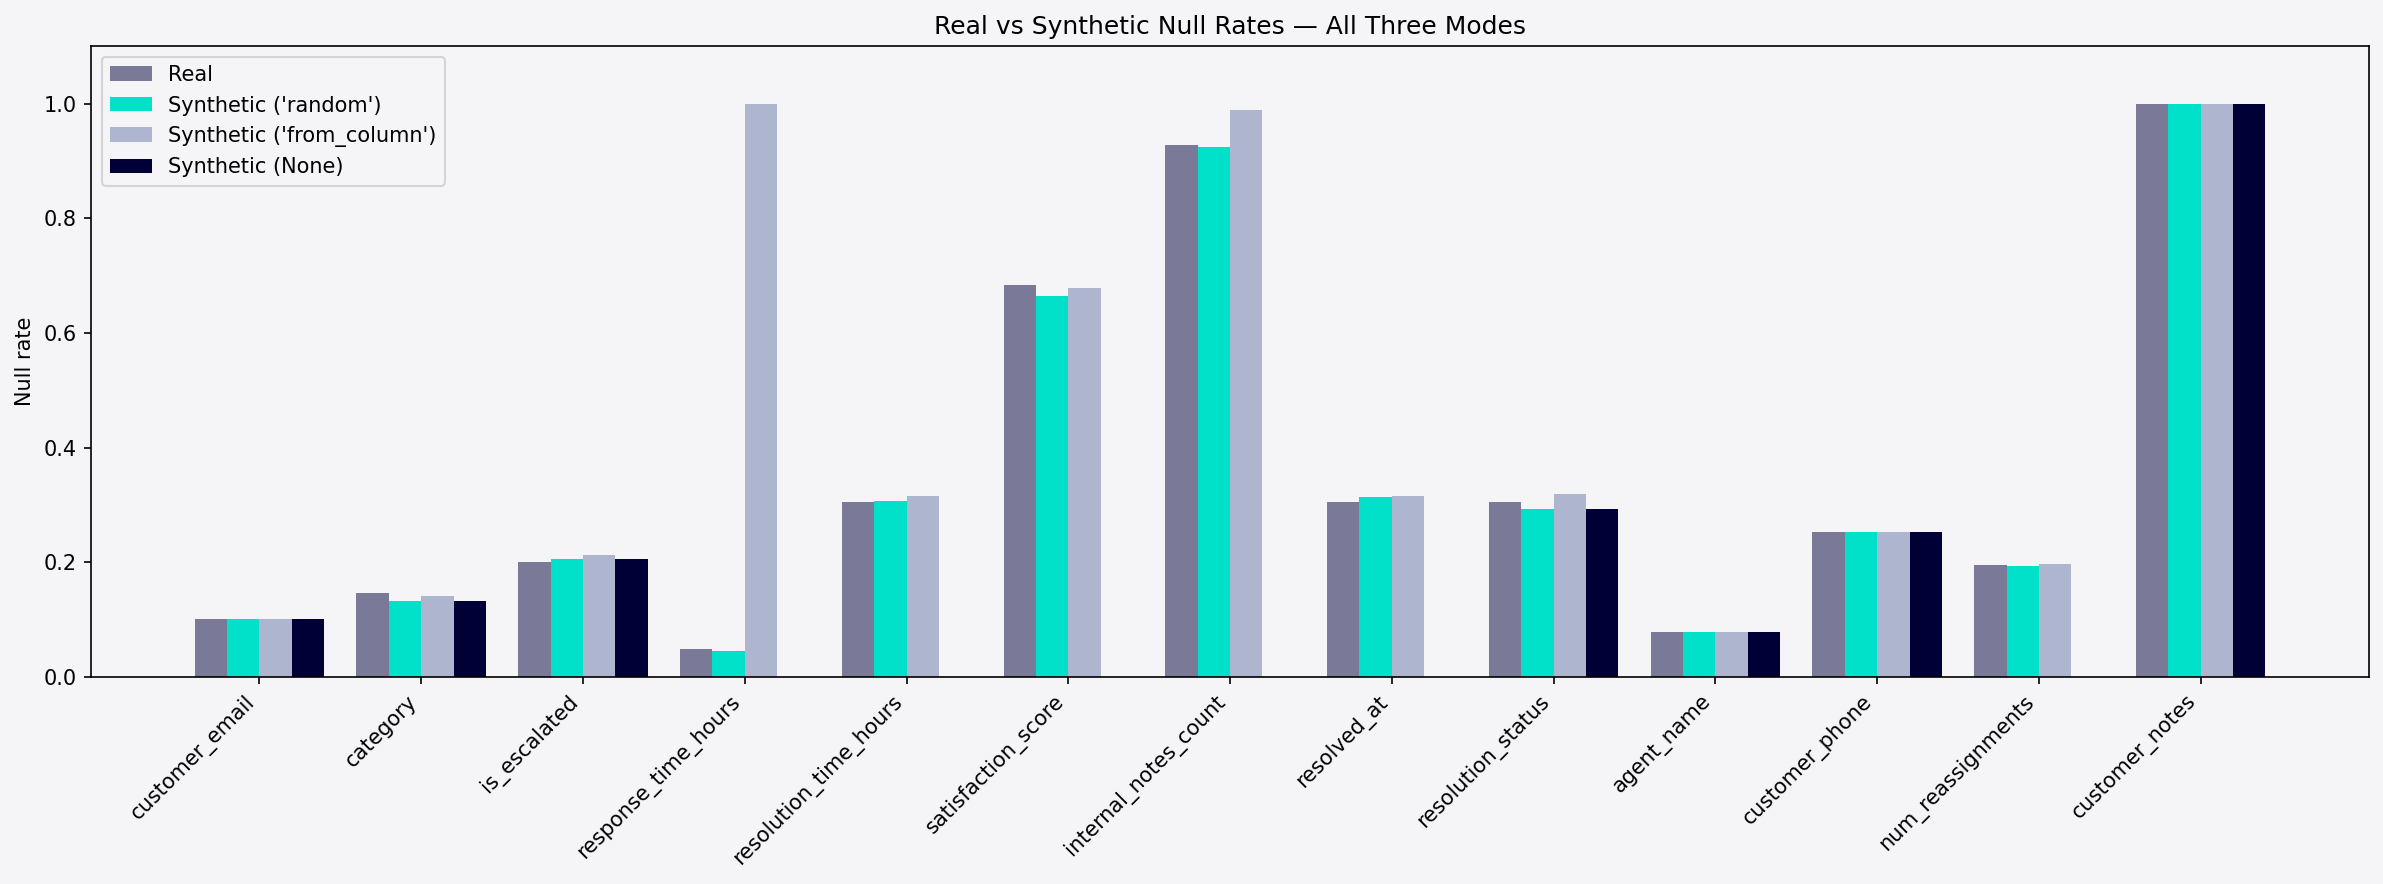

A few things stand out in the comparison:

- **`'random'`** closely matches the real null rates across all columns. This is the safest default.
- **`'from_column'`** can sometimes produce very different null rates. Notice `response_time_hours` jumping to 100% null (vs 4.9% real) — this is a known behavior with GaussianCopula, which we explore in the *Interesting Cases with Null Values in SDV* cookbook.
- **`None`** eliminates nulls for numerical and datetime columns, but categorical columns (`category`, `is_escalated`) and PII columns (`customer_email`, `agent_name`, `customer_phone`) still show nulls because they handle missingness differently.

> **Key takeaway:** Use `'random'` (default) unless you specifically need null patterns tied to other columns.

## 6. Cleaning placeholder values before synthesis

A common real-world pattern is using placeholder values like `-1`, `999`, or `"N/A"` instead of actual nulls. SDV does not detect these as missing — it treats them as legitimate data points and will reproduce them in the synthetic output.

Our dataset has two versions of response time that illustrate this:
- `response_time_hours` — uses proper `NaN` for missing values (~5% null)
- `response_time_legacy` — uses `-1.0` as a placeholder (0% null from SDV's perspective)

**Does our dataset have any placeholders?**

In [11]:
print('response_time_hours (proper NaN):')
print(f'  Null count: {data["response_time_hours"].isnull().sum()}')
print(f'  Min value:  {data["response_time_hours"].min():.2f}')
print()
print('response_time_legacy (-1 placeholder):')
print(f'  Null count: {data["response_time_legacy"].isnull().sum()}')
print(f'  -1 count:   {(data["response_time_legacy"] == -1.0).sum()}')
print(f'  Min value:  {data["response_time_legacy"].min():.2f}')

response_time_hours (proper NaN):
  Null count: 98
  Min value:  0.10

response_time_legacy (-1 placeholder):
  Null count: 0
  -1 count:   98
  Min value:  -1.00


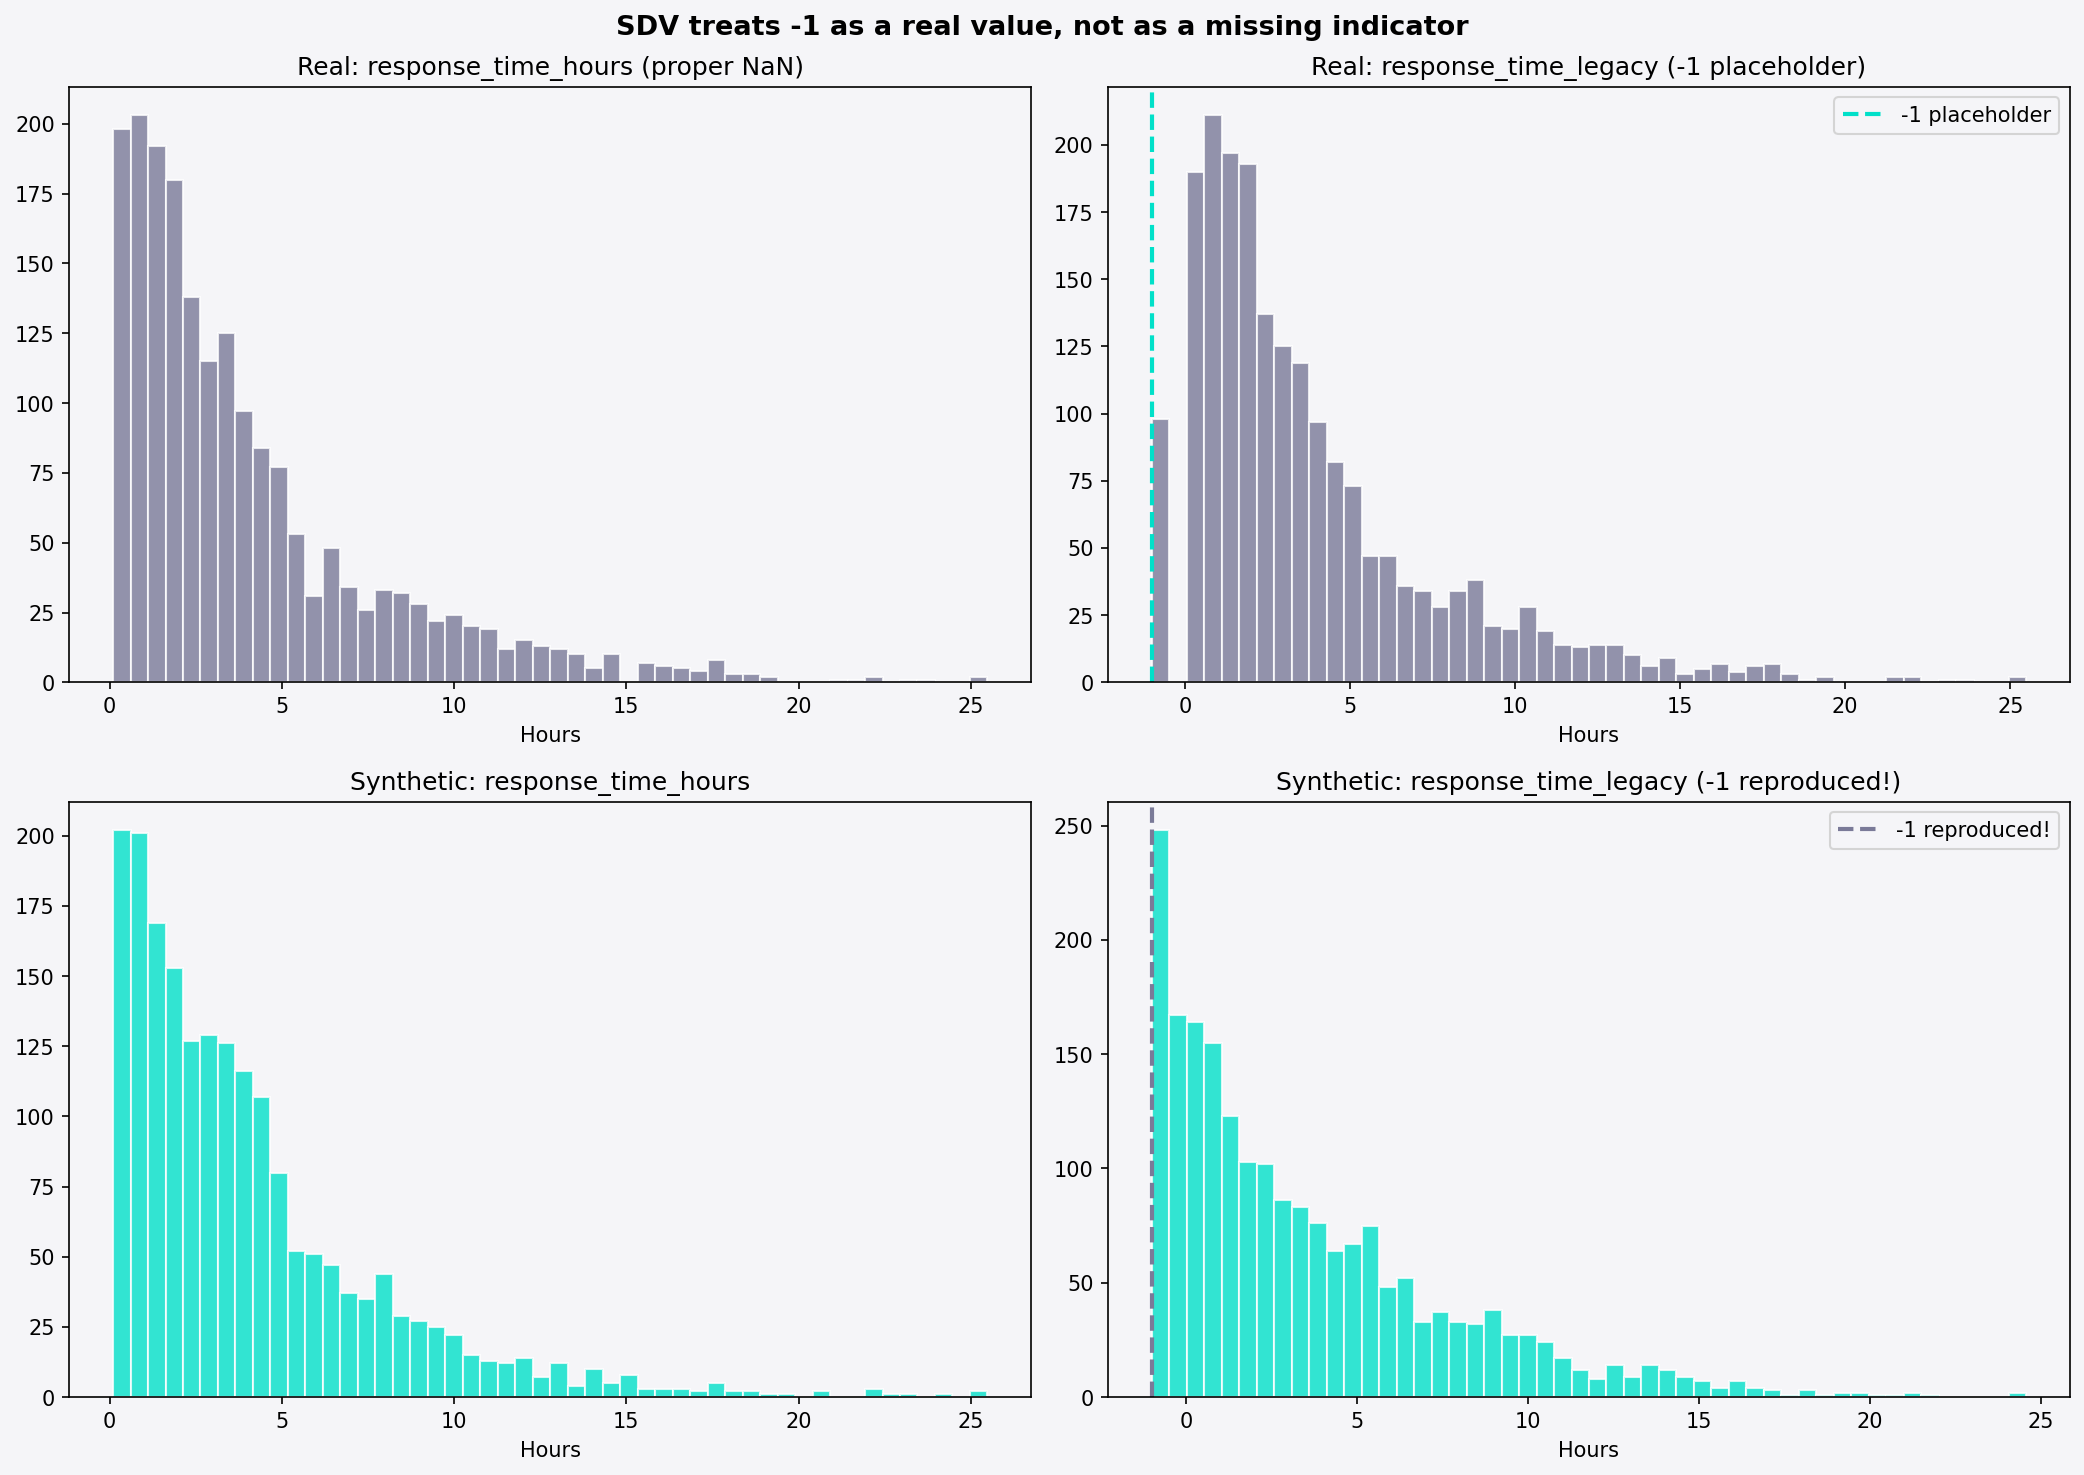

The synthetic data faithfully reproduces `-1` values in `response_time_legacy` because SDV learned them as real data points. Always convert placeholders to `NaN` before fitting:

```python
data = data.replace(-1, np.nan)
data = data.replace('', np.nan)
```

Also watch for empty strings — `pd.isna()` does not flag `""` as missing, so these need to be converted explicitly.

## 7. Preserving correlated null patterns

In our dataset, three columns are always null or non-null together: `resolution_time_hours`, `resolved_at`, and `resolution_status`. This makes sense — they all describe the resolution of a support ticket, so if a ticket isn't resolved, all three fields are missing. This is a **correlated null pattern**.

By default, SDV's `'random'` mode treats each column independently when deciding which synthetic rows should have nulls. This breaks the correlation — you'll see rows where `resolution_time_hours` is null but `resolution_status` is not, which would never happen in the real data.

**Does the default synthesizer preserve this correlation?**

In [12]:
correlated_cols = ['resolution_time_hours', 'resolved_at', 'resolution_status']

real_null_pattern = data[correlated_cols].isnull()
real_all_same = (real_null_pattern.nunique(axis=1) == 1).all()
print(f'Real data — nulls always aligned: {real_all_same}')

synth_null_pattern = synthetic_data[correlated_cols].isnull()
synth_all_same = (synth_null_pattern.nunique(axis=1) == 1).all()
print(f'Synthetic data — nulls always aligned: {synth_all_same}')

if not synth_all_same:
    misaligned = (synth_null_pattern.nunique(axis=1) > 1).sum()
    print(f'  Rows with broken correlation: {misaligned} / {len(synthetic_data)}')

Real data — nulls always aligned: True
Synthetic data — nulls always aligned: False
  Rows with broken correlation: 1274 / 2000


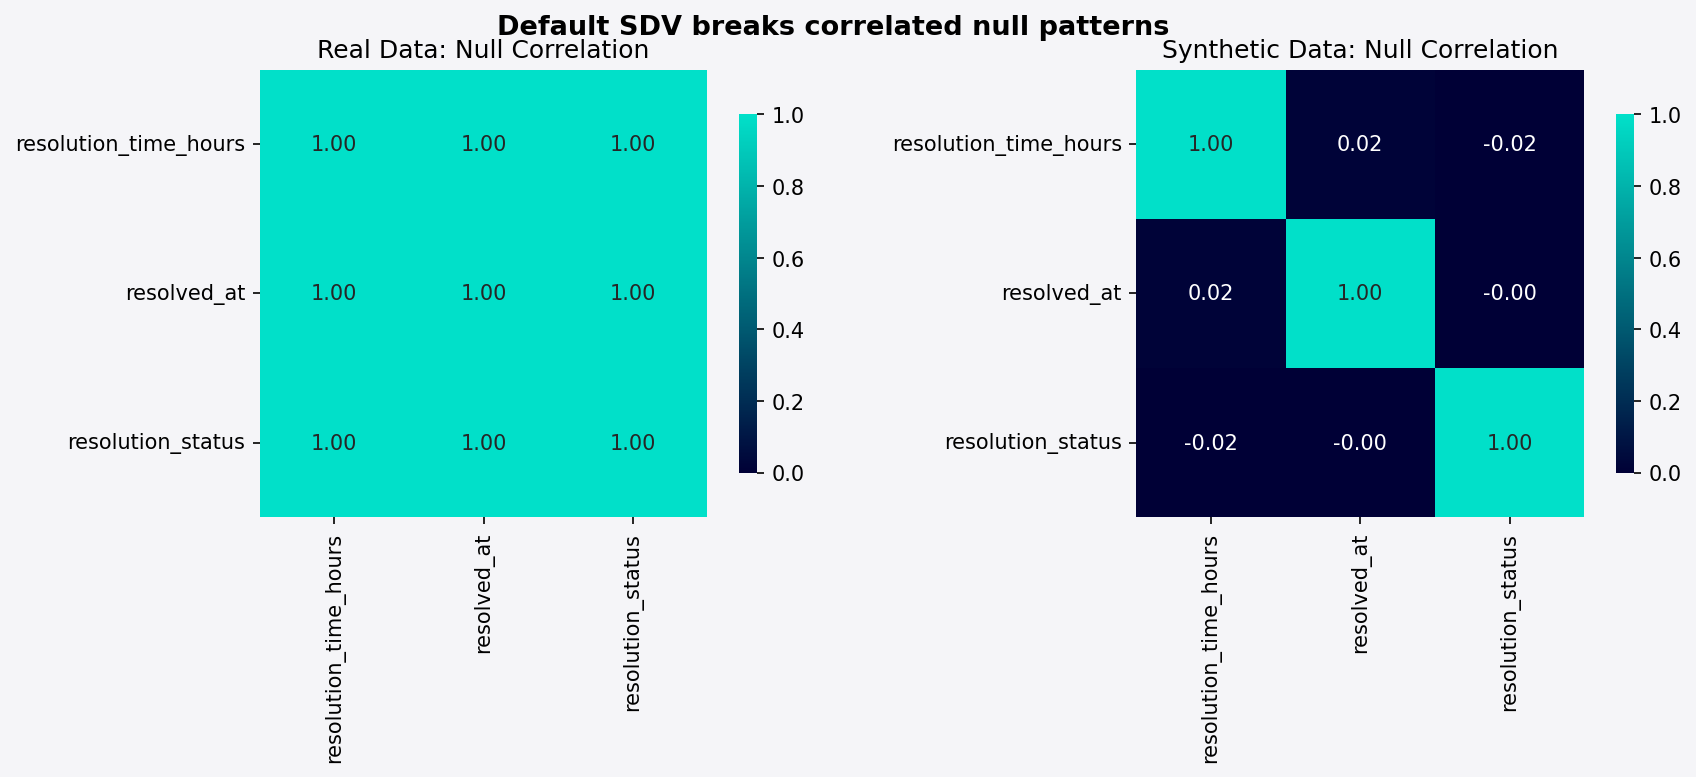

The null correlation in the real data is perfect (1.0 across all pairs), but the synthetic data shows much weaker correlation. We can reduce this by switching to `'from_column'` mode on the correlated columns, which tells the synthesizer to learn *when* these values should be null:

In [13]:
from rdt.transformers.numerical import FloatFormatter
from rdt.transformers.datetime import UnixTimestampEncoder

fc_corr_synth = GaussianCopulaSynthesizer(metadata)
fc_corr_synth.auto_assign_transformers(data)
fc_corr_synth.update_transformers(phone_transformer())

fc_corr_synth.update_transformers({
    'resolution_time_hours': FloatFormatter(
        missing_value_replacement='mean',
        missing_value_generation='from_column'
    ),
    'resolved_at': UnixTimestampEncoder(
        missing_value_generation='from_column'
    ),
})

fc_corr_synth.fit(data)
fc_corr_synthetic = fc_corr_synth.sample(num_rows=2000)

**Did `from_column` mode improve the correlation?**

In [14]:
fc_corr_null_pattern = fc_corr_synthetic[correlated_cols].isnull()
fc_corr_misaligned = (fc_corr_null_pattern.nunique(axis=1) > 1).sum()

print(f'Default (random) — misaligned rows: '
      f'{(synth_null_pattern.nunique(axis=1) > 1).sum()} / {len(synthetic_data)}')
print(f'from_column — misaligned rows: '
      f'{fc_corr_misaligned} / {len(fc_corr_synthetic)}')

Default (random) — misaligned rows: 1274 / 2000
from_column — misaligned rows: 356 / 2000


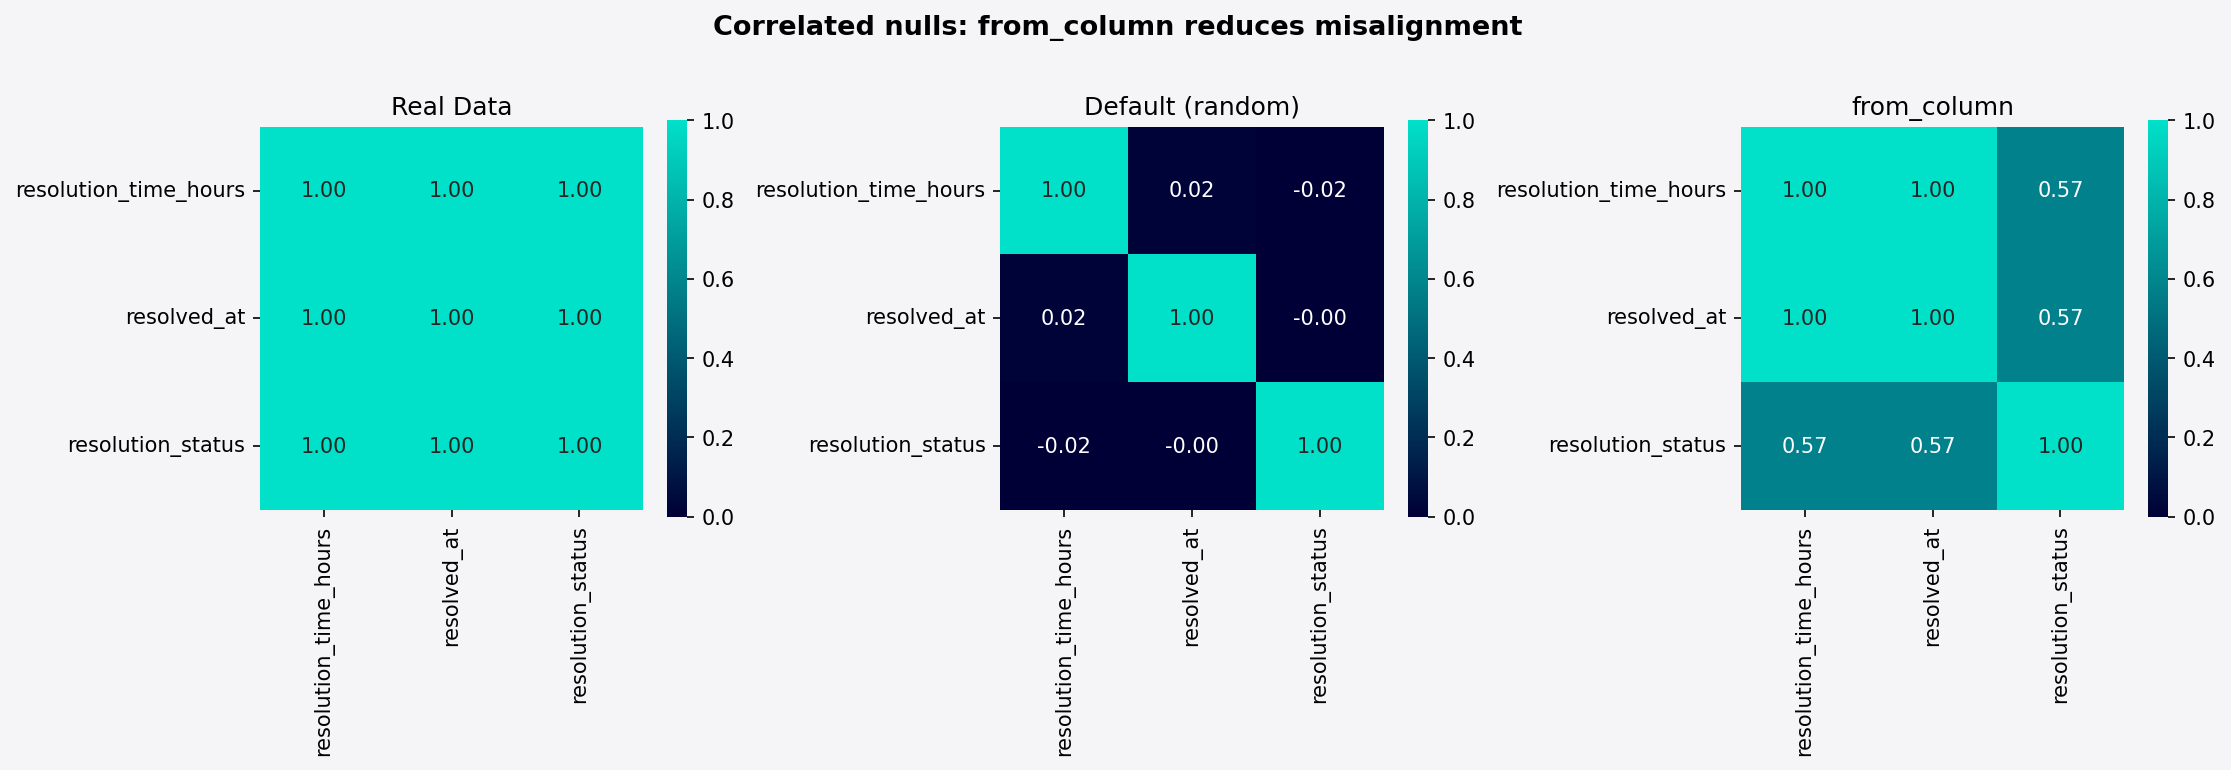

`'from_column'` reduces misalignment significantly but doesn't guarantee perfect alignment — each indicator column is modeled independently by the synthesizer.

For strict enforcement, SDV Enterprise offers `FixedNullCombinations` — a constraint purpose-built for enforcing null co-occurrence patterns. It locks the null/non-null structure while still allowing flexibility in how non-null values combine.

## 8. Customizing null handling per column

You can mix and match null modes across columns using `update_transformers()`. This lets you apply `'from_column'` where missingness is meaningful, `None` where a column must be complete, and leave the default `'random'` for everything else.

The two key parameters on each transformer are:
- **`missing_value_generation`** — controls how nulls reappear in synthetic data (`'random'`, `'from_column'`, or `None`)
- **`missing_value_replacement`** — controls what value replaces nulls during training (default: `'mean'`; alternative: `'random'`, which chooses a value uniformly at random from the column's min/max range)

In [15]:
custom = GaussianCopulaSynthesizer(metadata)
custom.auto_assign_transformers(data)
custom.update_transformers(phone_transformer())

# Use 'from_column' for the correlated resolution group
custom.update_transformers({
    'resolution_time_hours': FloatFormatter(
        missing_value_replacement='mean',
        missing_value_generation='from_column'
    ),
    'resolved_at': UnixTimestampEncoder(
        missing_value_generation='from_column'
    ),
})

# Eliminate nulls entirely for satisfaction_score
custom.update_transformers({
    'satisfaction_score': FloatFormatter(
        missing_value_replacement='mean',
        missing_value_generation=None
    ),
})

custom.fit(data)
custom_result = custom.sample(num_rows=2000)

print(f'satisfaction_score null rate — Real: {data["satisfaction_score"].isnull().mean():.1%}, '
      f'Synthetic: {custom_result["satisfaction_score"].isnull().mean():.1%}')

satisfaction_score null rate — Real: 68.4%, Synthetic: 0.0%


## 9. Recommendations

| Scenario | Recommended approach |
|----------|---------------------|
| Nulls are random / no meaningful pattern | `'random'` (default) — no configuration needed |
| Missingness is meaningful or correlated with other features | `'from_column'` via `update_transformers()` |
| Column must have zero nulls in synthetic output | `None` via `update_transformers()` |
| Columns are always null together | `'from_column'` mode + `FixedNullCombinations` constraint (Enterprise) |
| Data uses `-1`, `"N/A"`, or `""` as missing indicators | Convert to `NaN` before fitting |

**Checklist before submitting synthetic data:**

1. **Replace placeholders** with `NaN` before fitting — SDV doesn't auto-detect `-1`, `999`, `"N/A"`, or empty strings
2. **Compare null rates** after sampling: `synthetic_data.isnull().mean()` vs `data.isnull().mean()`
3. **Run `evaluate_quality()`** for a full quality assessment including null rate similarity
4. **Test constraints** on a small data subset first — null-related constraint errors are among the most common SDV issues

## Conclusion

SDV handles missing values automatically. The default behavior preserves null rates without any configuration — just fit and sample. When you need more control, `update_transformers()` lets you choose how each column handles nulls, and constraints like `FixedCombinations` can enforce correlated null patterns.

The most important step is data preparation: always convert placeholder values to `NaN` before fitting, and validate null rates after sampling.